<a href="https://colab.research.google.com/github/Santibareiro27/Inteligencia-Computacional/blob/alex/RA1_LAB1/Datos_Laboratorio_N%C2%B01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Datos - Laboratorio N°1

In [56]:
# @title Importación, visualización, manipulación de datos
!pip install lazypredict
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy import stats
import pickle
import time
import warnings
from sklearn.model_selection import (train_test_split, cross_val_score,
                                      StratifiedKFold, GridSearchCV)
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from lazypredict.Supervised import LazyClassifier
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (classification_report, confusion_matrix,
                              f1_score, accuracy_score, balanced_accuracy_score,
                              ConfusionMatrixDisplay, make_scorer)
from sklearn.feature_selection import mutual_info_classif, RFECV
from sklearn.inspection import permutation_importance
from sklearn.ensemble import RandomForestClassifier
import time




---


## Experiencia 2: Monitor de calidad de aire en espacios de trabajo

**Dataset:** `datos_adl.csv`  

**Grupo 8:** — Alex Nahuel Acosta, Santiago Daniel Bareiro, Agustín Marcelo Borges

**Fecha:** — dd/mm/aaaa

---

> Dispositivo IoT embebido de bajo costo para clasificación autónoma de situaciones de riesgo en ambientes cerrados.

---

### 0. Carga y exploración de datos

In [57]:
# Archivos pueden arrastrarse al área de trabajo o procesarse en local

# Versión en Línea
!wget https://raw.githubusercontent.com/Santibareiro27/Inteligencia-Computacional/main/RA1_LAB1/datos_adl.csv

--2026-04-09 20:16:37--  https://raw.githubusercontent.com/Santibareiro27/Inteligencia-Computacional/main/RA1_LAB1/datos_adl.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 54724 (53K) [text/plain]
Saving to: ‘datos_adl.csv.1’

datos_adl.csv.1     100%[===================>]  53.44K  --.-KB/s    in 0.01s   

2026-04-09 20:16:37 (4.41 MB/s) - ‘datos_adl.csv.1’ saved [54724/54724]



In [58]:
# Lectura del dataset
dataset_adl = pd.read_csv("datos_adl.csv")
dataset_adl

,MQ2,MQ9,MQ135,MQ137,MQ138,MG-811,Situacion
0,670,696,1252,1720,1321,2431,4
1,641,674,1156,1652,1410,2433,4
2,642,646,1159,1643,1455,2361,4
3,640,590,1105,1608,1459,2427,4
4,616,627,1192,1637,1466,2447,4
...,...,...,...,...,...,...,...
1840,862,826,1564,1768,1540,2037,4
1841,917,821,1571,1779,1543,2008,4
1842,925,832,1582,1776,1545,1989,4
1843,928,840,1587,1787,1538,1986,4


In [59]:
dataset_adl.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1845 entries, 0 to 1844
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   MQ2        1845 non-null   int64
 1   MQ9        1845 non-null   int64
 2   MQ135      1845 non-null   int64
 3   MQ137      1845 non-null   int64
 4   MQ138      1845 non-null   int64
 5   MG-811     1845 non-null   int64
 6   Situacion  1845 non-null   int64
dtypes: int64(7)
memory usage: 101.0 KB


No hay valores nulos, todos los datos son de tipo entero, la dataset pesa 101 KB

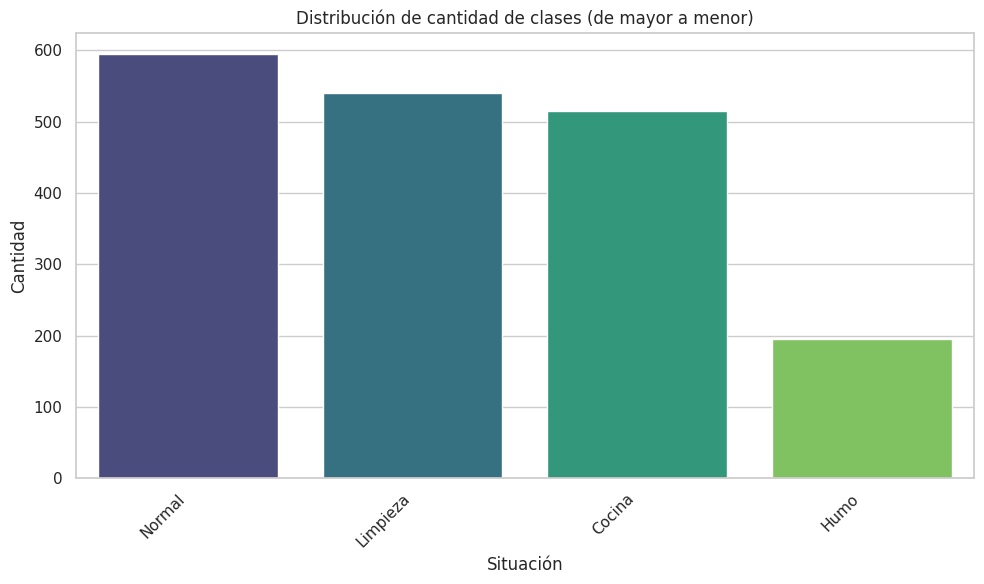

In [60]:
import matplotlib.pyplot as plt
import seaborn as sns

situacion_counts = dataset_adl['Situacion'].value_counts().sort_values(ascending=False)

situacion_labels = {
    1: 'Normal',
    2: 'Cocina',
    3: 'Humo',
    4: 'Limpieza'
}

# Mapea las situaciones numéricas a sus etiquetas descriptivas para la gráfica
labels = [situacion_labels[s] for s in situacion_counts.index]

plt.figure(figsize=(10, 6))
sns.barplot(x=labels, y=situacion_counts.values, hue=labels, palette='viridis', legend=False)
plt.title('Distribución de cantidad de clases (de mayor a menor)')
plt.xlabel('Situación')
plt.ylabel('Cantidad')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [61]:
total_instances = situacion_counts.sum()

percentages = (situacion_counts / total_instances) * 100

print("Porcentaje de cada clase:")
for situacion_id, count in situacion_counts.items():
    label = situacion_labels.get(situacion_id, f'Situacion {situacion_id}')
    percentage = percentages[situacion_id]
    print(f"- {label}: {percentage:.2f}%")

Porcentaje de cada clase:
- Normal: 32.25%
- Limpieza: 29.27%
- Cocina: 27.91%
- Humo: 10.57%


Hay un claro desbalance de clases, la de humo posee 3 veces menos muestras que la normal.

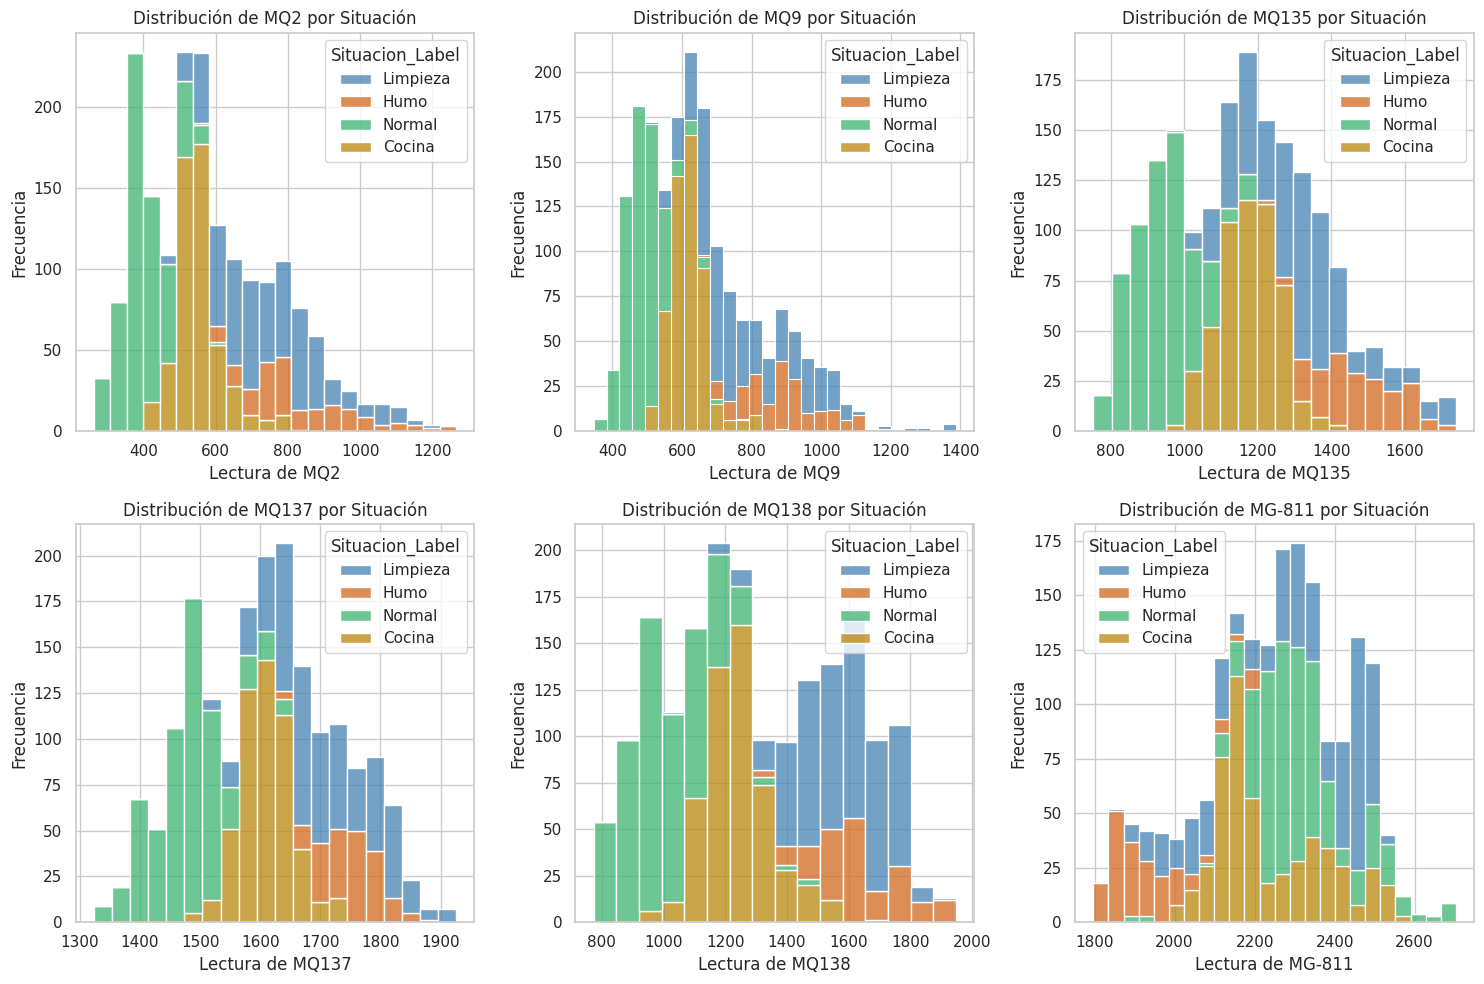

In [62]:
if 'dataset_adl' not in globals():
    try:
        dataset_adl = pd.read_csv("datos_adl.csv")
    except FileNotFoundError:
        print("Error: 'datos_adl.csv' no encontrado. Asegúrate de que el archivo esté descargado o especifica la ruta correcta.")
        raise

sensor_columns = ['MQ2', 'MQ9', 'MQ135', 'MQ137', 'MQ138', 'MG-811']


fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(15, 10))
axes = axes.flatten()

dataset_adl_labeled = dataset_adl.copy()
dataset_adl_labeled['Situacion_Label'] = dataset_adl_labeled['Situacion'].map(situacion_labels)

custom_palette = {
    'Humo': 'chocolate',
    'Limpieza': 'steelblue',
    'Cocina': 'darkgoldenrod',
    'Normal': 'mediumseagreen'
}

for i, sensor in enumerate(sensor_columns):
    # Grafica el histograma para cada sensor, con el tono basado en 'Situacion_Label' y la paleta personalizada
    sns.histplot(data=dataset_adl_labeled, x=sensor, hue='Situacion_Label', multiple='stack', ax=axes[i], kde=False, palette=custom_palette)
    axes[i].set_title(f'Distribución de {sensor} por Situación')
    axes[i].set_xlabel(f'Lectura de {sensor}')
    axes[i].set_ylabel('Frecuencia')


plt.tight_layout()
plt.show()

Hay sensores que se destacan en detectar bien ciertas situaciones, el MQ 811 el caso de humo, el MQ 138 separa bien las situaciones mas cotidianas pero no el humo, etc. Y se observa que trabajan en distintos rangos numéricos, habria que normalizar los datos para luego entrenar a un modelo

/tmp/ipykernel_1330/319186670.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_1330/319186670.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_1330/319186670.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_1330/319186670.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_1330/319186670.py:26: FutureWarning: 

Passin

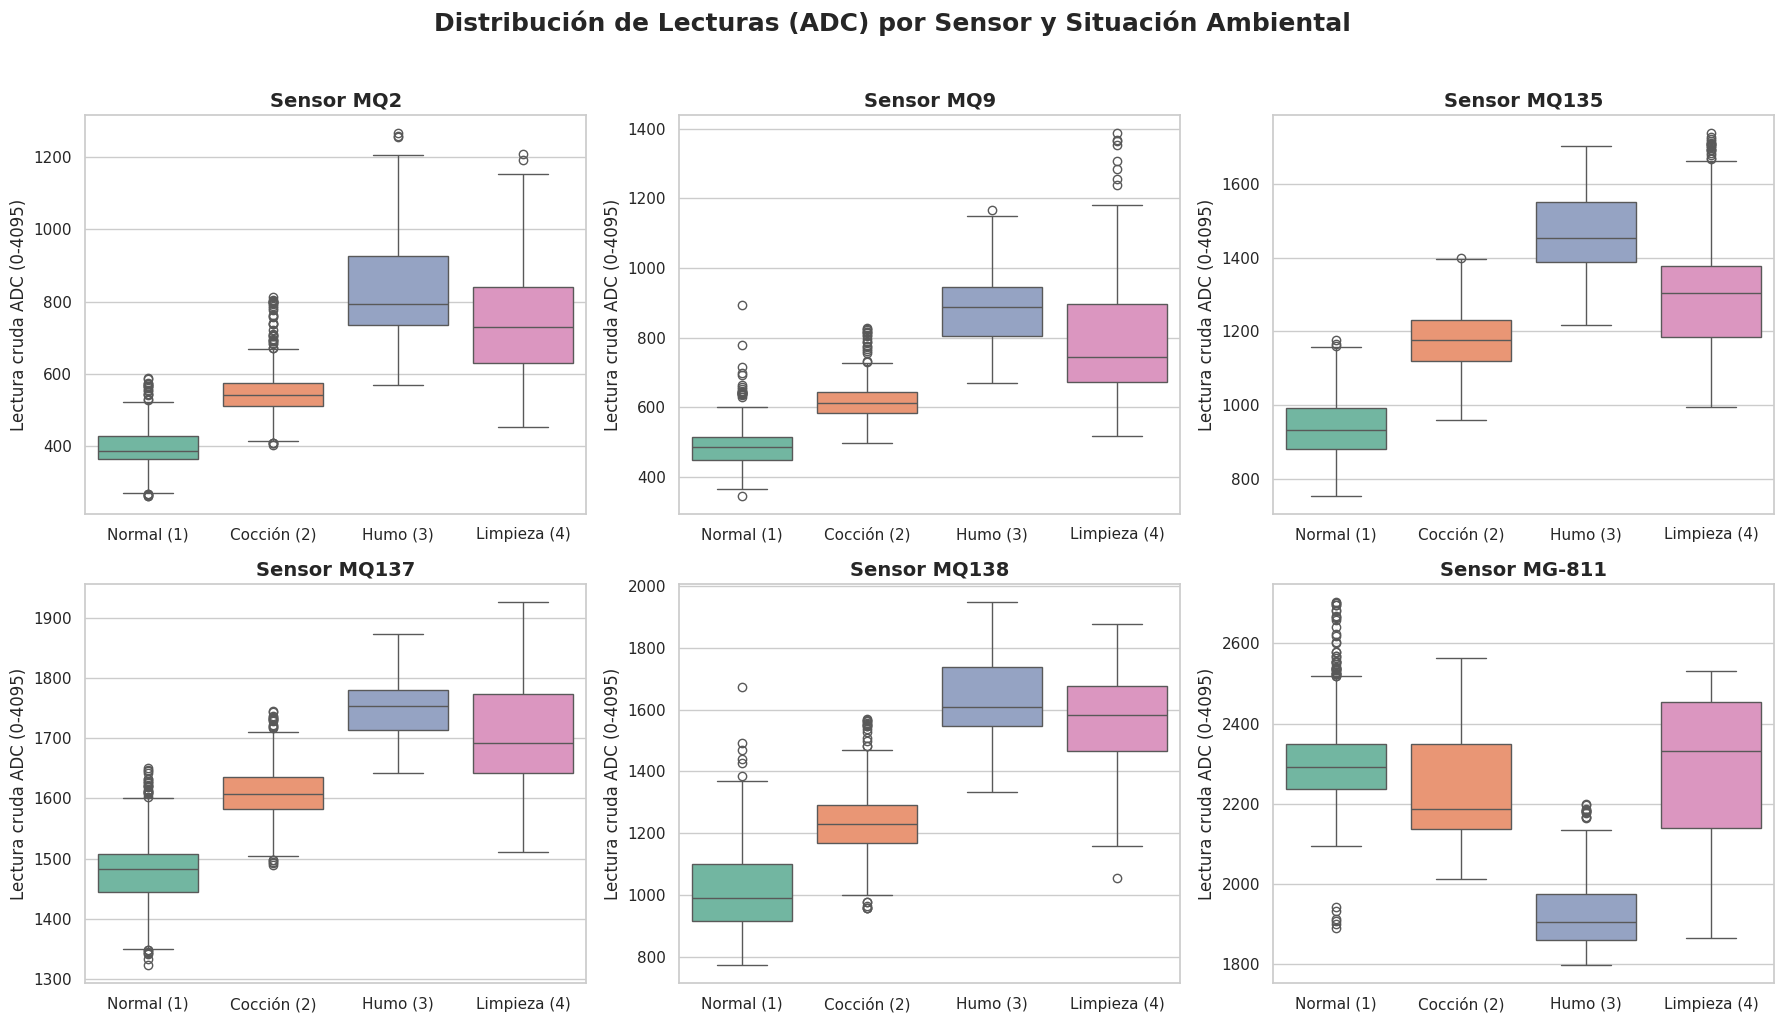

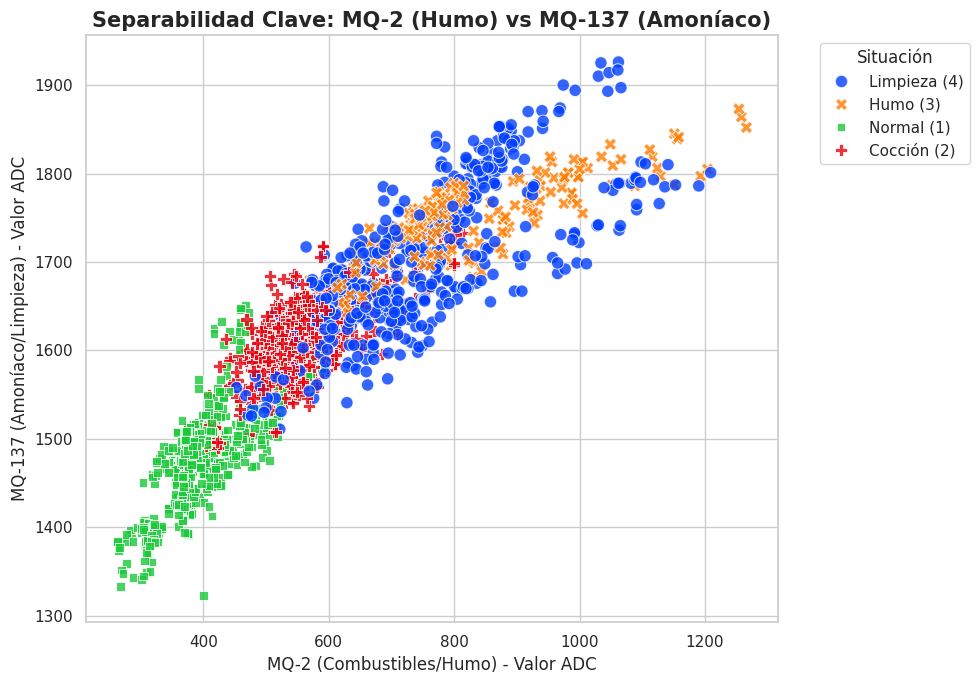

In [63]:
# 1. Mapear las etiquetas numéricas a texto para que los gráficos sean autoexplicativos
etiquetas_situacion = {
    1: 'Normal (1)',
    2: 'Cocción (2)',
    3: 'Humo (3)',
    4: 'Limpieza (4)'
}
dataset_adl['Situacion_Nombre'] = dataset_adl['Situacion'].map(etiquetas_situacion)
orden_clases = ['Normal (1)', 'Cocción (2)', 'Humo (3)', 'Limpieza (4)']

# 2. Configurar el estilo de Seaborn
sns.set_theme(style="whitegrid")

# ==============================================================================
# GRÁFICO 1: Boxplots de cada sensor (Evidencia de sensibilidad)
# ==============================================================================
sensores = ['MQ2', 'MQ9', 'MQ135', 'MQ137', 'MQ138', 'MG-811']
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Distribución de Lecturas (ADC) por Sensor y Situación Ambiental', fontsize=18, fontweight='bold', y=1.02)

for i, sensor in enumerate(sensores):
    row = i // 3
    col = i % 3

    # Crear el boxplot
    sns.boxplot(
        data=dataset_adl,
        x='Situacion_Nombre',
        y=sensor,
        ax=axes[row, col],
        palette='Set2',
        order=orden_clases
    )

    axes[row, col].set_title(f'Sensor {sensor}', fontsize=14, fontweight='bold')
    axes[row, col].set_xlabel('')
    axes[row, col].set_ylabel('Lectura cruda ADC (0-4095)')

plt.tight_layout()
plt.show()

# ==============================================================================
# GRÁFICO 2: Scatter plot de Separabilidad (Humo vs Limpieza)
# ==============================================================================
plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=df,
    x='MQ2',
    y='MQ137',
    hue='Situacion_Nombre',
    palette='bright',
    style='Situacion_Nombre',
    s=80,
    alpha=0.8
)

plt.title('Separabilidad Clave: MQ-2 (Humo) vs MQ-137 (Amoníaco)', fontsize=15, fontweight='bold')
plt.xlabel('MQ-2 (Combustibles/Humo) - Valor ADC', fontsize=12)
plt.ylabel('MQ-137 (Amoníaco/Limpieza) - Valor ADC', fontsize=12)
plt.legend(title='Situación', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

Las boxplots terminan de corroborar que sensores se destacan para ciertas clases. El scatter plot permite visualizar que los posibles mejores modelos a utilizar son el KNN y arbol de decisión, mientras la RAM sea suficiente.

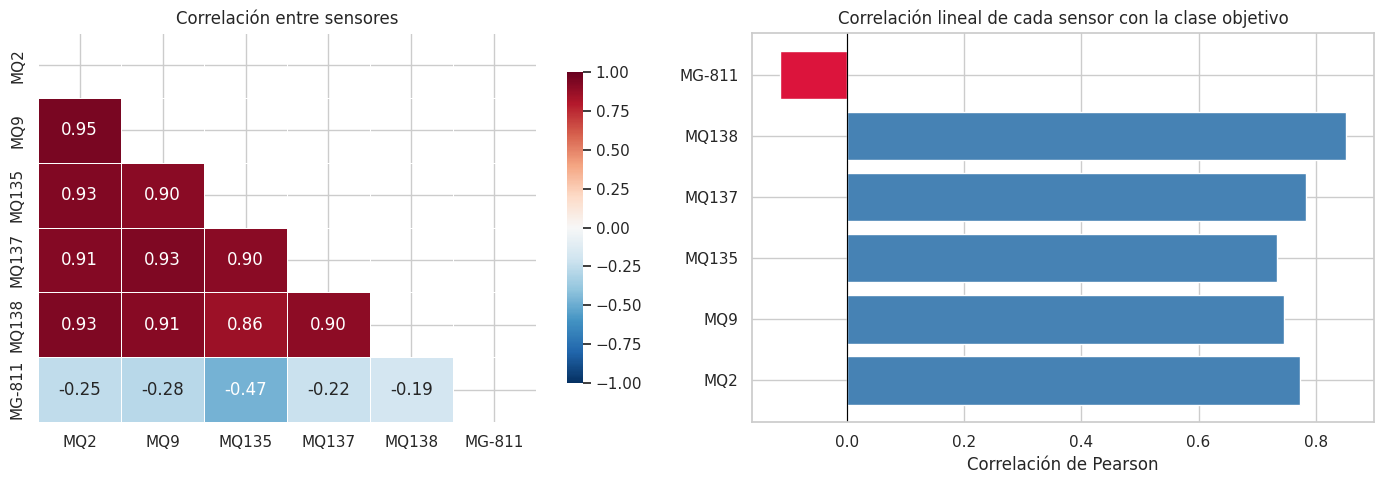

Correlaciones entre sensores MQ:
         MQ2    MQ9  MQ135  MQ137  MQ138
MQ2    1.000  0.947  0.928  0.915  0.934
MQ9    0.947  1.000  0.904  0.934  0.909
MQ135  0.928  0.904  1.000  0.900  0.858
MQ137  0.915  0.934  0.900  1.000  0.896
MQ138  0.934  0.909  0.858  0.896  1.000


In [64]:
sensores = ["MQ2", "MQ9", "MQ135", "MQ137", "MQ138", "MG-811"]
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Correlación completa
corr = dataset_adl[sensores].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, vmin=-1, vmax=1, mask=mask,
            ax=axes[0], linewidths=0.5, cbar_kws={"shrink": 0.8})
axes[0].set_title("Correlación entre sensores", fontsize=12)

# Correlación con el target
corr_target = dataset_adl[sensores + ["Situacion"]].corr()["Situacion"].drop("Situacion")
colors_bar = ["steelblue" if v > 0 else "crimson" for v in corr_target]
axes[1].barh(corr_target.index, corr_target.values, color=colors_bar, edgecolor="white")
axes[1].axvline(0, color="black", linewidth=0.8)
axes[1].set_title("Correlación lineal de cada sensor con la clase objetivo", fontsize=12)
axes[1].set_xlabel("Correlación de Pearson")

plt.tight_layout()
plt.show()

print("Correlaciones entre sensores MQ:")
mq_cols = ["MQ2", "MQ9", "MQ135", "MQ137", "MQ138"]
mq_corr = dataset_adl[mq_cols].corr()
print(mq_corr.round(3))

La familia de sensores MQ miden de forma similar, por eso tienen una alta correlación, y se observa como el MG recopila los datos de forma distinta.

Según la scatter plot los mejores modelos pueden ser arboles de decisión y KNN habria que corroborar eso, pero no descartar aún otros modelos.

In [66]:
# Mapeo de la variable objetivo (Situacion)
# Original: 1 (normal), 2 (coccion), 3 (humo), 4 (limpieza)
# Nuevo: 1 (normal), 2 (cocina), 3 (limpieza), 4 (humo)
remapping = {1: 1, 2: 2, 4: 3, 3: 4}
dataset_adl['Situacion'] = dataset_adl['Situacion'].map(remapping)

# Comprobar la nueva distribución
print("--- NUEVA DISTRIBUCIÓN DE CLASES ---")
print(dataset_adl['Situacion'].value_counts().sort_index())

# Separar Features (X) y Target (y)
# Drop 'Situacion_Nombre' as it's a string representation of the target and not a feature
X = dataset_adl.drop(['Situacion', 'Situacion_Nombre'], axis=1)
y = dataset_adl['Situacion']

# Train/Test Split (Estratificado)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Normalización (MinMaxScaler recomendado para IoT)
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Probar múltiples modelos
models = {
    "Regresión Logística": LogisticRegression(max_iter=1000, random_state=42),
    "Árbol de Decisión": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "SVM (Lineal)": SVC(kernel='linear', random_state=42),
    "SVM (RBF)": SVC(kernel='rbf', random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5)
}

results = []
for name, model in models.items():
    # Tiempo de entrenamiento
    start_train = time.time()
    model.fit(X_train_scaled, y_train)
    end_train = time.time()

    # Tiempo de inferencia
    start_pred = time.time()
    y_pred = model.predict(X_test_scaled)
    end_pred = time.time()

    # Métricas
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')

    results.append({
        "Modelo": name,
        "Accuracy": round(acc, 4),
        "F1-Score": round(f1, 4),
        "T. Entrenamiento (s)": round(end_train - start_train, 5),
        "T. Inferencia (s)": round(end_pred - start_pred, 5)
    })

results_df = pd.DataFrame(results).sort_values(by="Accuracy", ascending=False)
print("\n--- COMPARACIÓN DE MODELOS ---")
print(results_df.to_string(index=False))

--- NUEVA DISTRIBUCIÓN DE CLASES ---
Situacion
1    595
2    515
3    195
4    540
Name: count, dtype: int64

--- COMPARACIÓN DE MODELOS ---
             Modelo  Accuracy  F1-Score  T. Entrenamiento (s)  T. Inferencia (s)
                KNN    0.9729    0.9729               0.00184            0.00408
      Random Forest    0.9621    0.9622               0.40562            0.00982
          SVM (RBF)    0.9404    0.9404               0.02172            0.01007
  Árbol de Decisión    0.9322    0.9325               0.01183            0.00050
       SVM (Lineal)    0.9079    0.9084               0.01973            0.00633
Regresión Logística    0.8862    0.8865               0.02076            0.00053


se reordeno las situaciones para clasificarlas según la importancia del contexto de decteción de situaciones de mayor importancia, se normalizó los datos.

In [68]:
# 2. Entrenar Random Forest con TODOS los sensores
rf_all = RandomForestClassifier(random_state=42, n_estimators=100)
rf_all.fit(X_train_scaled, y_train)

# 3. Extraer Importancia de Variables
importances = rf_all.feature_importances_
feature_names = X.columns
feat_imp_df = pd.DataFrame({'Sensor': feature_names, 'Importancia': importances})
feat_imp_df = feat_imp_df.sort_values(by='Importancia', ascending=False)

print("--- IMPORTANCIA DE SENSORES (TODOS INCLUIDOS) ---")
print(feat_imp_df.to_string(index=False))

# Define target_names for classification reports
target_names = ['Normal', 'Cocina', 'Limpieza', 'Humo']

# 4. Reporte de Clasificación (Todos los sensores)
y_pred_all = rf_all.predict(X_test_scaled)
print("\n--- REPORTE DE CLASIFICACIÓN (TODOS LOS SENSORES) ---")
print(classification_report(y_test, y_pred_all, target_names=target_names))

# 5. Experimento: Entrenar SIN el MG-811
X_train_no_mg811 = np.delete(X_train_scaled, 5, axis=1) # El índice 5 es MG-811
X_test_no_mg811 = np.delete(X_test_scaled, 5, axis=1)

rf_no_mg811 = RandomForestClassifier(random_state=42, n_estimators=100)
rf_no_mg811.fit(X_train_no_mg811, y_train)
y_pred_no_mg811 = rf_no_mg811.predict(X_test_no_mg811)

print("\n--- REPORTE DE CLASIFICACIÓN (SIN MG-811) ---")
print(classification_report(y_test, y_pred_no_mg811, target_names=target_names))


--- IMPORTANCIA DE SENSORES (TODOS INCLUIDOS) ---
Sensor  Importancia
 MQ138     0.190649
   MQ9     0.186716
 MQ135     0.180532
 MQ137     0.173501
   MQ2     0.137104
MG-811     0.131497

--- REPORTE DE CLASIFICACIÓN (TODOS LOS SENSORES) ---
              precision    recall  f1-score   support

      Normal       1.00      0.97      0.99       119
      Cocina       0.94      0.96      0.95       103
    Limpieza       0.93      0.95      0.94        39
        Humo       0.95      0.95      0.95       108

    accuracy                           0.96       369
   macro avg       0.96      0.96      0.96       369
weighted avg       0.96      0.96      0.96       369


--- REPORTE DE CLASIFICACIÓN (SIN MG-811) ---
              precision    recall  f1-score   support

      Normal       1.00      0.97      0.98       119
      Cocina       0.93      0.95      0.94       103
    Limpieza       0.97      0.87      0.92        39
        Humo       0.91      0.96      0.94       108

 